In [60]:
import os
os.chdir('/ictstr01/home/icb/fatemehs.hashemig/codes/interpretable-ssl')

In [61]:
from interpretable_ssl.evaluation.metric_helpers.metacell_plots import *

# pbmc-immune

In [64]:
immune_home = '/home/icb/fatemehs.hashemig/models/pbmc-immune/'
p_dict = {'seacell': f'{immune_home}/seacell/metrics/', 'scproto': f'{immune_home}/10X-scproto/'}

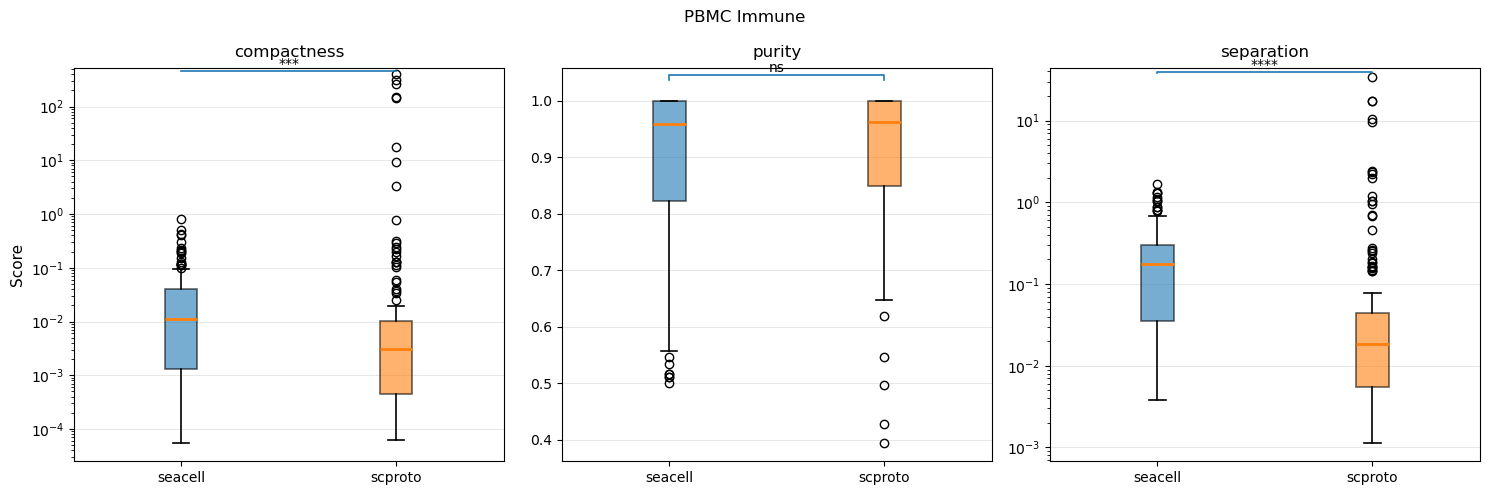

In [65]:
plot(p_dict, 'PBMC Immune')

In [ ]:
# 

In [47]:
p_dict = {'seacell': f'{immune_home}/seacell/metrics/', 'scproto': f'{immune_home}/10X-scproto/'}

In [48]:
model_dfs = {model_name: {m: pd.read_csv(f'{path}/{m}') for m in metrics} for model_name, path in p_dict.items()}

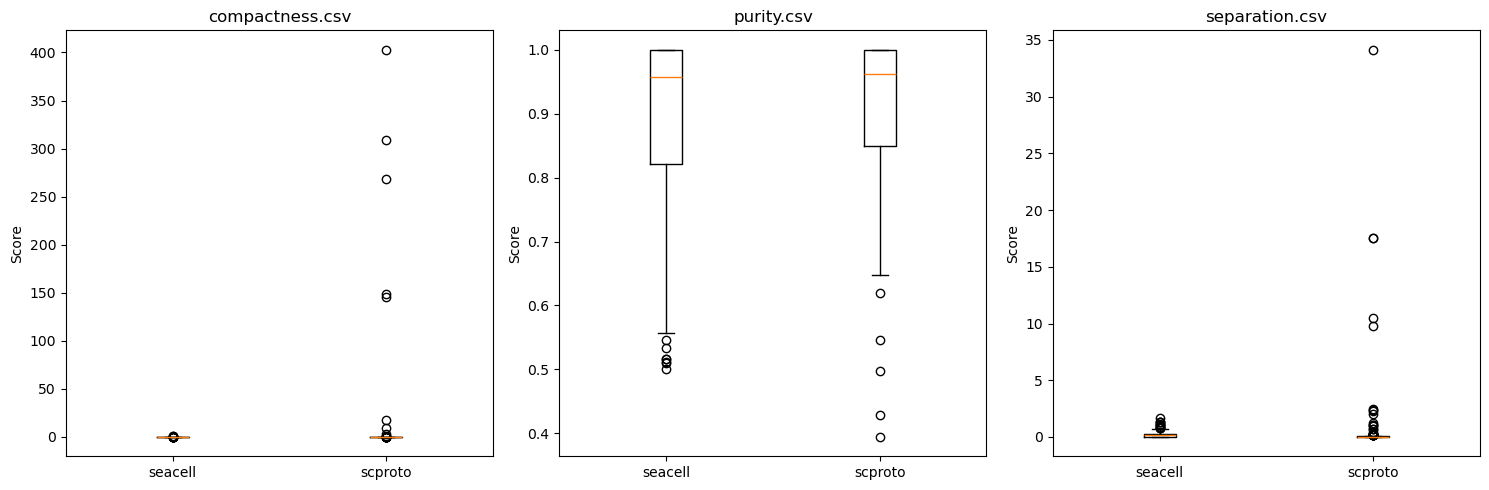

In [36]:
import matplotlib.pyplot as plt

# Create one subplot per metric
fig, axes = plt.subplots(1, len(metrics), figsize=(15, 5), sharey=False)

if len(metrics) == 1:  # if only one metric, axes won't be an array
    axes = [axes]

for mid, metric in enumerate(metrics):
    ax = axes[mid]

    # collect values from each model for this metric
    data = []
    labels = []

    for model_name, model_df_dict in model_dfs.items():
        df = model_df_dict[metric]   # df for this model+metric
        data.append(df[df.columns[-1]])     # numeric column
        labels.append(model_name)    # x-axis label

    
    # make boxplot with all models side by side
    ax.boxplot(data, labels=labels)
    ax.set_title(metric)
    ax.set_ylabel("Score")

plt.tight_layout()
plt.show()


In [49]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.stats import mannwhitneyu

# --- helpers ---------------------------------------------------------------
def p_to_stars(p):
    # Two-sided Wilcoxon rank-sum (Mann–Whitney U) thresholds:
    # ns: p > 0.05; *: 0.01 < p <= 0.05; **: 0.001 < p <= 0.01; ***: 0.0001 < p <= 0.001; ****: p <= 0.0001
    if p <= 1e-4: return "****"
    if p <= 1e-3: return "***"
    if p <= 1e-2: return "**"
    if p <= 0.05: return "*"
    return "ns"

def add_sig_bar(ax, x1, x2, y, h, label, lw=1.2):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], linewidth=lw)
    ax.text((x1+x2)/2, y+h, label, ha='center', va='bottom', fontsize=10)

def collect_values(df, value_col=None):
    if value_col is None:
        # use the last column by default
        vals = np.asarray(df[df.columns[-1]], dtype=float)
    else:
        vals = np.asarray(df[value_col], dtype=float)
    return vals[~np.isnan(vals)]

# --- main ---------------------------------------------------------------
def plot_metric_boxpanels(
    model_dfs,                      # dict: model -> dict(metric -> df)
    metrics,                        # list of metric keys to plot
    value_col=None,                 # str or None; if None, use last column
    model_order=None,               # list of models in desired plotting order
    comparisons='auto',             # list of (modelA, modelB) per panel, or 'auto'
    ylabel="Score",
    log_metrics=None,               # set of metric names to plot on log-scale
    figsize=(15, 5),
    title = None
):
    if log_metrics is None:
        log_metrics = set()
    if model_order is None:
        model_order = list(model_dfs.keys())

    # prepare figure
    fig, axes = plt.subplots(1, len(metrics), figsize=figsize, sharey=False)
    if len(metrics) == 1:
        axes = [axes]

    # p-values to return
    all_pvals = {}

    for midx, metric in enumerate(metrics):
        ax = axes[midx]

        # gather values
        data = []
        labels = []
        for m in model_order:
            vals = collect_values(model_dfs[m][metric], value_col=value_col)
            data.append(vals)
            labels.append(m)

        # draw boxplot — patch_artist to lightly color boxes
        bp = ax.boxplot(
            data,
            labels=labels,
            whis=1.5,            # 1.5 * IQR
            showfliers=True,     # show outliers as points
            notch=False,
            patch_artist=True,   # allow filled boxes
            medianprops=dict(linewidth=2),
            boxprops=dict(linewidth=1.2),
            whiskerprops=dict(linewidth=1.2),
            capprops=dict(linewidth=1.2),
        )

        # softly fill boxes (use matplotlib default color cycle)
        cycle_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
        for i, patch in enumerate(bp['boxes']):
            patch.set_facecolor(cycle_colors[i % len(cycle_colors)])
            patch.set_alpha(0.6)

        # axis cosmetics like the paper
        nice_title = metric.replace(".csv", "")
        ax.set_title(nice_title, fontsize=12, pad=8)
        if midx == 0:
            ax.set_ylabel(ylabel, fontsize=11)
        ax.grid(True, axis='y', linewidth=0.6, alpha=0.35)

        # log scale for skewed metrics (optional)
        if metric in log_metrics:
            ax.set_yscale("log")

        # significance comparisons (Wilcoxon rank-sum / Mann–Whitney U, two-sided)
        if comparisons == 'auto':
            # default: compare the first model to every other model to avoid clutter
            pairs = [(model_order[0], m) for m in model_order[1:]]
        else:
            pairs = list(comparisons)

        # map model -> x position (1-based in boxplot)
        xpos = {m: i+1 for i, m in enumerate(model_order)}

        # base height for bars
        # work in data units (log-aware)
        vals_concat = np.concatenate([v for v in data if len(v) > 0]) if len(data) else np.array([1.0])
        y_min = float(np.nanmin(vals_concat)) if len(vals_concat) else 0.0
        y_max = float(np.nanmax(vals_concat)) if len(vals_concat) else 1.0

        if metric in log_metrics:
            # multiplicative spacing above max
            bar_y = y_max * 1.12
            step  = (y_max ** 1.25) / (y_max ** 1.12)  # not actually used; we’ll just multiply
            step_mult = 1.18
        else:
            rng = (y_max - y_min) if y_max > y_min else (abs(y_max) + 1.0)
            bar_y = y_max + 0.06 * rng
            step = 0.07 * rng

        pvals_for_metric = {}
        for k, (a, b) in enumerate(pairs):
            va = collect_values(model_dfs[a][metric], value_col=value_col)
            vb = collect_values(model_dfs[b][metric], value_col=value_col)
            if len(va) == 0 or len(vb) == 0:
                continue
            # Mann–Whitney U (two-sided)
            U, p = mannwhitneyu(va, vb, alternative='two-sided', method='auto')
            pvals_for_metric[(a, b)] = p

            # place bracket
            x1, x2 = xpos[a], xpos[b]
            if metric in log_metrics:
                y = bar_y * (step_mult ** k)
                h = y * 0.03
            else:
                y = bar_y + k * step
                h = 0.015 * (y_max - y_min if y_max > y_min else 1.0)

            add_sig_bar(ax, x1, x2, y, h, p_to_stars(p))

        all_pvals[metric] = pvals_for_metric

        # slightly expand top for headroom
        if metric in log_metrics:
            ax.set_ylim(top=y*1.15)
        else:
            ax.set_ylim(top=(bar_y + max(0.5*step, 0.02*(y_max - y_min))))

        # tidy ticklabel size
        ax.tick_params(axis='both', labelsize=10)
    if title is not None:
        fig.suptitle(title)
    plt.tight_layout()
    return fig, axes, all_pvals


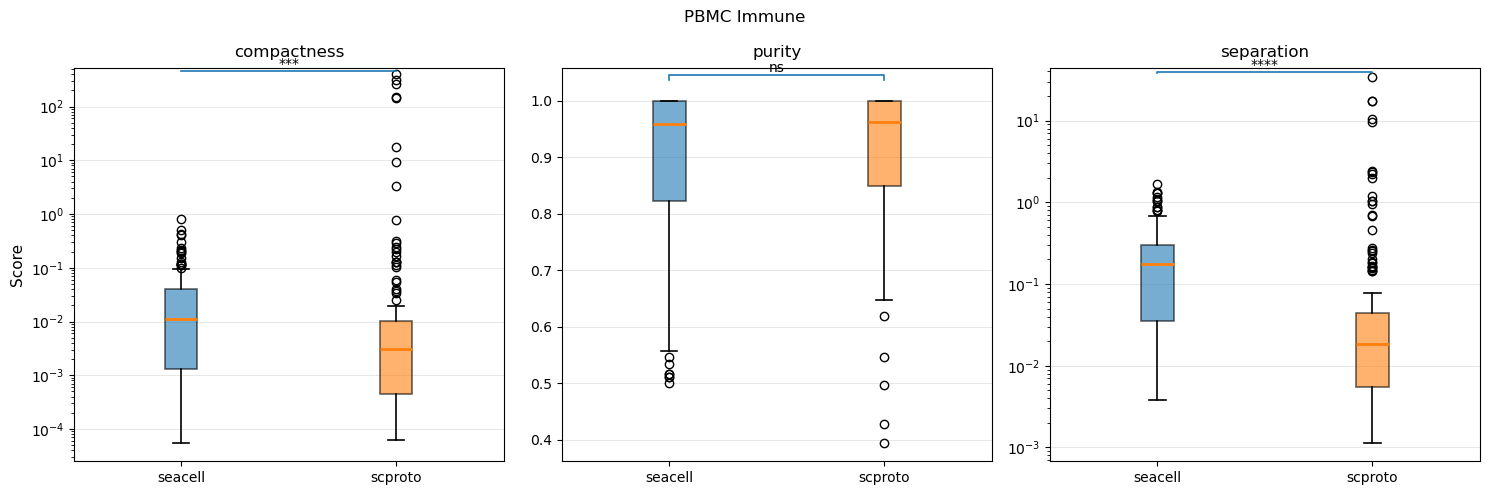

In [50]:
metrics = ["compactness.csv", "purity.csv", "separation.csv"]

# optional: put skewed metrics on log scale for readability
log_metrics = {"compactness.csv", "separation.csv"}

# choose model order and comparisons for stars (first vs others by default)
model_order = ["seacell", "scproto"]  # change as needed
comparisons = "auto"  # or e.g. [("seacell","scproto"), ("seacell","methodX")]

fig, axes, pvals = plot_metric_boxpanels(
    model_dfs=model_dfs,
    metrics=metrics,
    value_col=None,          # last column holds values in your CSV dfs
    model_order=model_order,
    comparisons=comparisons,
    ylabel="Score",
    log_metrics=log_metrics,
    figsize=(5*len(metrics), 5),
    title = 'PBMC Immune'
)

plt.show()

# p-values dictionary:
# pvals["compactness.csv"][("seacell","scproto")] -> 0.00032, etc.


# same plots for cd3+

In [38]:
pwd

'/ictstr01/home/icb/fatemehs.hashemig/codes/interpretable-ssl/notebooks'

In [51]:
home = '/ictstr01/home/icb/fatemehs.hashemig/'
p_dict = {'seacell': f'{home}/models/cd34/seacell/', 'scproto': f'{home}/models/cd34/scproto/'}

In [52]:
model_dfs = {model_name: {m: pd.read_csv(f'{path}/{m}') for m in metrics} for model_name, path in p_dict.items()}

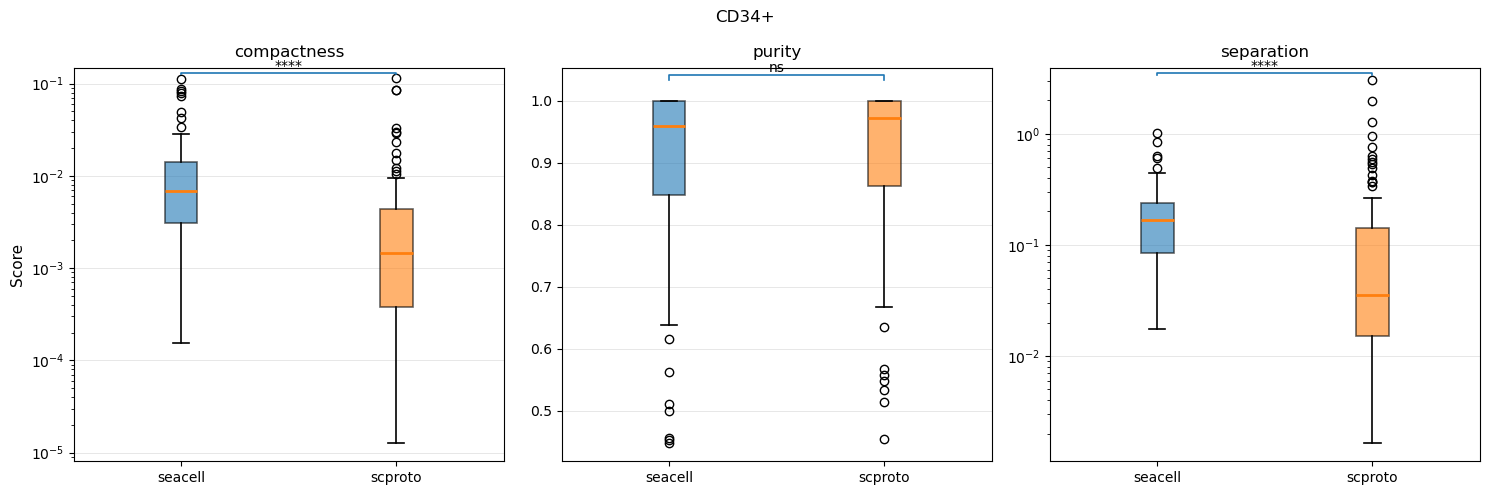

In [53]:
metrics = ["compactness.csv", "purity.csv", "separation.csv"]

# optional: put skewed metrics on log scale for readability
log_metrics = {"compactness.csv", "separation.csv"}

# choose model order and comparisons for stars (first vs others by default)
model_order = ["seacell", "scproto"]  # change as needed
comparisons = "auto"  # or e.g. [("seacell","scproto"), ("seacell","methodX")]

fig, axes, pvals = plot_metric_boxpanels(
    model_dfs=model_dfs,
    metrics=metrics,
    value_col=None,          # last column holds values in your CSV dfs
    model_order=model_order,
    comparisons=comparisons,
    ylabel="Score",
    log_metrics=log_metrics,
    figsize=(5*len(metrics), 5),
    title = 'CD34+'
)

plt.show()

# p-values dictionary:
# pvals["compactness.csv"][("seacell","scproto")] -> 0.00032, etc.


# same for pancreas

In [55]:
p_dict = {'seacell': f'{home}/models/pancreas/inDrop3-seacell/', 'scproto': f'{home}/models/pancreas/inDrop3-scproto/'}

In [56]:
model_dfs = {model_name: {m: pd.read_csv(f'{path}/{m}') for m in metrics} for model_name, path in p_dict.items()}

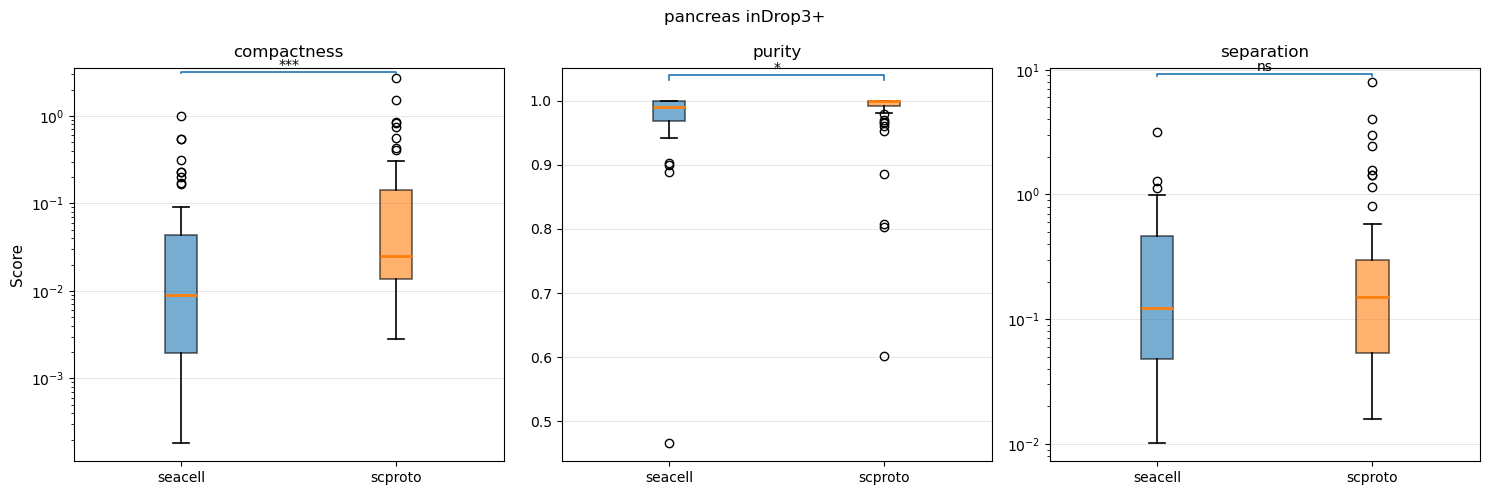

In [58]:
fig, axes, pvals = plot_metric_boxpanels(
    model_dfs=model_dfs,
    metrics=metrics,
    value_col=None,          # last column holds values in your CSV dfs
    model_order=model_order,
    comparisons=comparisons,
    ylabel="Score",
    log_metrics=log_metrics,
    figsize=(5*len(metrics), 5),
    title = 'pancreas inDrop3+'
)

plt.show()